In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [36]:
df = pd.read_csv(r"C:\Users\Shivam kumar\Desktop\PROJECT\Electricity-Consumption\data\powerconsumption.csv")
df.head()

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [37]:
df.shape

(52416, 9)

**DATA DESCRIPTION**

 - datetime -> shows the date and time
 - temperature -> shows the temperature of the area (Celsius)
 - Humidity -> shows the humidity present in the atmosphere (% percentage)
 - WindSpeed -> shows the speed of wind meter per second (m/s)
 - GeneralDiffuseFlows -> shows the solar radiation watts/square meter (W/m2)
 - DiffuseFlows -> shows the solar radiation component watts/square meter (W/m2)

 - PowerConsumption(zone1,zone2,zone3) -> total electricity consumption in the zone kilowatts (kW)

In [38]:
# the data is for every 10 minute interval

In [39]:
df.columns

Index(['Datetime', 'Temperature', 'Humidity', 'WindSpeed',
       'GeneralDiffuseFlows', 'DiffuseFlows', 'PowerConsumption_Zone1',
       'PowerConsumption_Zone2', 'PowerConsumption_Zone3'],
      dtype='object')

In [40]:
df.isnull().sum()

Datetime                  0
Temperature               0
Humidity                  0
WindSpeed                 0
GeneralDiffuseFlows       0
DiffuseFlows              0
PowerConsumption_Zone1    0
PowerConsumption_Zone2    0
PowerConsumption_Zone3    0
dtype: int64

In [41]:
df.duplicated().sum()

0

In [42]:
df.describe()

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
count,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,18.810024,68.259518,1.959489,182.696614,75.028022,32344.970564,21042.509082,17835.406218
std,5.815476,15.551177,2.348862,264.400960,124.210949,7130.562564,5201.465892,6622.165099
min,3.247000,11.340000,0.050000,0.004000,0.011000,13895.696200,8560.081466,5935.174070
25%,14.410000,58.310000,0.078000,0.062000,0.122000,26310.668692,16980.766032,13129.326630
50%,18.780000,69.860000,0.086000,5.035500,4.456000,32265.920340,20823.168405,16415.117470
75%,22.890000,81.400000,4.915000,319.600000,101.000000,37309.018185,24713.717520,21624.100420
max,40.010000,94.800000,6.483000,1163.000000,936.000000,52204.395120,37408.860760,47598.326360


In [43]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')
df.set_index('Datetime', inplace=True)

# Convert 10-minute data to hourly
df_hourly = df.resample('H').mean()

df_hourly.head()

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
Datetime,,,,,,,,
2017-01-01 00:00:00,6.196833,75.066667,0.081833,0.063500,0.098833,29197.974683,18026.747720,19252.048193
2017-01-01 01:00:00,5.548833,77.583333,0.082000,0.056833,0.112500,24657.215190,16078.419453,17042.891567
2017-01-01 02:00:00,5.054333,78.933333,0.082333,0.063000,0.129167,22083.037973,14330.699088,15676.144578
2017-01-01 03:00:00,5.004333,77.083333,0.082833,0.059833,0.141000,20811.139240,13219.452887,14883.855422
2017-01-01 04:00:00,5.097667,74.050000,0.082333,0.058000,0.122833,20475.949367,12921.580547,14317.108433


In [44]:
# checking the hourly consumption

df_hourly['Hour'] = df_hourly.index.hour

hourly_pattern = df_hourly.groupby('Hour')[
    ['PowerConsumption_Zone1',
     'PowerConsumption_Zone2',
     'PowerConsumption_Zone3']
].mean()

hourly_pattern

,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
Hour,,,
0,30217.235372,19692.073550,18657.222811
1,27565.533030,17765.078949,16970.804696
2,26292.688917,16730.156092,15981.096176
3,25338.122851,16052.585288,15238.605002
4,24633.576717,15624.081077,14671.039080
5,23437.577276,14974.907723,13226.380008
6,23203.597394,14934.698604,12051.599729
7,24038.353352,15719.115067,11667.864458
8,26583.262396,17529.678454,12793.786057


Maximum power consumption is between (7pm to 9pm)

In [45]:
# Daily power consumption

df_hourly['Day'] = df_hourly.index.day_name()

daily_pattern = df_hourly.groupby('Day')[
    ['PowerConsumption_Zone1',
     'PowerConsumption_Zone2',
     'PowerConsumption_Zone3']
].mean()
daily_pattern

,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
Day,,,
Friday,32338.995905,21461.038263,17545.971382
Monday,32615.410633,21280.065085,17809.081562
Saturday,32253.034345,20585.955724,18011.187469
Sunday,30780.079481,18979.377434,17954.827782
Thursday,32842.484416,21845.164469,17843.692103
Tuesday,32713.030148,21518.599887,17831.688173
Wednesday,32871.759018,21627.362715,17851.395059


In Zone1 & Zone2 weekday(sunday) has less power consumption
In Zone3 Friday has less power consumption

In [46]:
# Monthly electricity consumption

df_hourly['Month'] = df_hourly.index.month

monthly_pattern = df_hourly.groupby('Month')[
    ['PowerConsumption_Zone1',
     'PowerConsumption_Zone2',
     'PowerConsumption_Zone3']
].mean()
monthly_pattern

,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
Month,,,
1,31032.493535,19394.444717,17746.095349
2,30985.753632,18787.793096,17335.002154
3,31155.165408,18457.937484,16947.686004
4,31169.768210,17633.966395,18593.167677
5,32396.009166,19977.287859,17621.100953
6,34605.540839,20670.928621,20430.941538
7,35831.553603,24147.886893,28194.111216
8,36435.189574,24656.216575,24648.894732
9,33396.681416,20180.432259,14922.798774


In June, July, August the electricity consumption is maximum

In [47]:
# Season based electricity consumption

def season(month):
    if month in (11,12,1):
        return 'Winter'
    elif month in (2,3,4):
        return 'Autumn'
    elif month in (5,6,7):
        return 'Summer'
    else:
        return 'Monsoon'
    
df_hourly['Season'] = df_hourly['Month'].apply(season)

season_pattern = df_hourly.groupby('Season')[
    ['PowerConsumption_Zone1',
     'PowerConsumption_Zone2',
     'PowerConsumption_Zone3']
].mean()

season_pattern

,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
Season,,,
Autumn,31106.789614,18283.969219,17624.195019
Monsoon,34228.791098,22122.766068,17641.159242
Summer,34274.137728,21608.785608,22099.998080
Winter,29701.050083,22075.794409,13926.901463


In Monsoon the electricity consumption is maximum

In [48]:
df_hourly.head()

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,Hour,Day,Month,Season
Datetime,,,,,,,,,,,,
2017-01-01 00:00:00,6.196833,75.066667,0.081833,0.063500,0.098833,29197.974683,18026.747720,19252.048193,0,Sunday,1,Winter
2017-01-01 01:00:00,5.548833,77.583333,0.082000,0.056833,0.112500,24657.215190,16078.419453,17042.891567,1,Sunday,1,Winter
2017-01-01 02:00:00,5.054333,78.933333,0.082333,0.063000,0.129167,22083.037973,14330.699088,15676.144578,2,Sunday,1,Winter
2017-01-01 03:00:00,5.004333,77.083333,0.082833,0.059833,0.141000,20811.139240,13219.452887,14883.855422,3,Sunday,1,Winter
2017-01-01 04:00:00,5.097667,74.050000,0.082333,0.058000,0.122833,20475.949367,12921.580547,14317.108433,4,Sunday,1,Winter


In [49]:
df_hourly.dtypes

Temperature               float64
Humidity                  float64
WindSpeed                 float64
GeneralDiffuseFlows       float64
DiffuseFlows              float64
PowerConsumption_Zone1    float64
PowerConsumption_Zone2    float64
PowerConsumption_Zone3    float64
Hour                        int32
Day                        object
Month                       int32
Season                     object
dtype: object

In [50]:
# Correlation checking

df_hourly_numeric = df_hourly.select_dtypes(include=['float64']).columns
df_hourly_numeric

Index(['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows',
       'DiffuseFlows', 'PowerConsumption_Zone1', 'PowerConsumption_Zone2',
       'PowerConsumption_Zone3'],
      dtype='object')

In [51]:
# Correlation check

correlation = df_hourly[df_hourly_numeric].corr()
correlation


,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
Temperature,1.000000,-0.459387,0.479446,0.464366,0.202537,0.443863,0.384833,0.492124
Humidity,-0.459387,1.000000,-0.136835,-0.473566,-0.266270,-0.290764,-0.297885,-0.235100
WindSpeed,0.479446,-0.136835,1.000000,0.136046,-0.001090,0.169573,0.147999,0.280995
GeneralDiffuseFlows,0.464366,-0.473566,0.136046,1.000000,0.576290,0.191831,0.159858,0.064914
DiffuseFlows,0.202537,-0.266270,-0.001090,0.576290,1.000000,0.087430,0.049046,-0.037074
PowerConsumption_Zone1,0.443863,-0.290764,0.169573,0.191831,0.087430,1.000000,0.834165,0.750057
PowerConsumption_Zone2,0.384833,-0.297885,0.147999,0.159858,0.049046,0.834165,1.000000,0.568448
PowerConsumption_Zone3,0.492124,-0.235100,0.280995,0.064914,-0.037074,0.750057,0.568448,1.000000


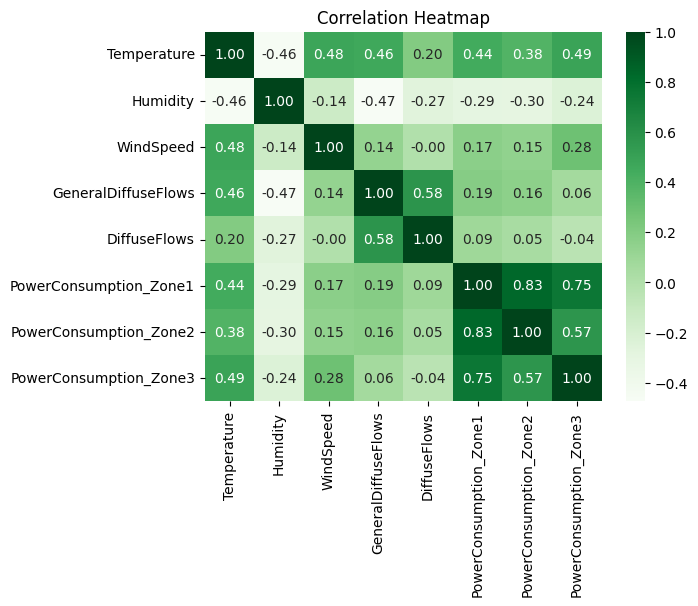

In [52]:
sns.heatmap(correlation,annot=True,cmap='Greens',fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [53]:
# checking the effect of temperature on electricity consumption

df_hourly['Temp_Bins'] = pd.cut(
    df_hourly['Temperature'],
    bins=5
)

temp_effect = df_hourly.groupby('Temp_Bins')[[
    'PowerConsumption_Zone1',
    'PowerConsumption_Zone3',
    'PowerConsumption_Zone3']
].mean()
temp_effect

,PowerConsumption_Zone1,PowerConsumption_Zone3,PowerConsumption_Zone3
Temp_Bins,,,
"(3.566, 10.821]",26021.092976,13762.393990,13762.393990
"(10.821, 18.039]",30503.030435,15875.100337,15875.100337
"(18.039, 25.258]",33423.903202,17742.896875,17742.896875
"(25.258, 32.476]",37613.139695,25204.963964,25204.963964
"(32.476, 39.695]",39658.890146,29735.008231,29735.008231


As Temperature increases the electricity consumption also increases

In [54]:
# Cheking the effect of humidity on electricity consumption

humidity_effect = df_hourly.groupby(
    pd.cut(df_hourly['Humidity'],bins=5)
)[["PowerConsumption_Zone1",
   "PowerConsumption_Zone2",
   "PowerConsumption_Zone3"]].mean()

humidity_effect

,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
Humidity,,,
"(12.628, 29.118]",38425.507508,25848.163906,26081.928768
"(29.118, 45.526]",35820.351949,23472.500313,21162.869781
"(45.526, 61.934]",33891.378055,22142.902181,18538.095738
"(61.934, 78.342]",32457.303197,21302.049736,17501.141235
"(78.342, 94.75]",29984.003899,19143.729909,16557.500738


When humidity is low the electricity consumption is high

In [55]:
# Cheking the effect of Solar Radiation on electricity consumption

solar_effect = df_hourly.groupby(
    pd.cut(df_hourly['GeneralDiffuseFlows'],bins=5)
)[["PowerConsumption_Zone1",
   "PowerConsumption_Zone2",
   "PowerConsumption_Zone3"]].mean()

solar_effect

,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
GeneralDiffuseFlows,,,
"(-0.934, 190.685]",31608.375244,20529.282551,17860.545961
"(190.685, 381.351]",32493.538489,21439.837896,16223.639413
"(381.351, 572.018]",33120.240402,22134.679341,16472.434203
"(572.018, 762.684]",34876.387560,22065.166732,18955.222946
"(762.684, 953.35]",36632.403476,23398.767582,21923.801968


When Solar Radiation is high the electricity consumption is high

In [56]:
# Cheking the effect of Wind Speed on electricity consumption

wind_effect = df_hourly.groupby(
    pd.cut(df_hourly['WindSpeed'],bins=5)
)[["PowerConsumption_Zone1",
   "PowerConsumption_Zone2",
   "PowerConsumption_Zone3"]].mean()

wind_effect

,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
WindSpeed,,,
"(0.0488, 1.23]",31392.568293,20425.285576,16364.115589
"(1.23, 2.406]",32056.774898,21215.005915,15669.787812
"(2.406, 3.582]",33973.000601,23520.315426,17465.952846
"(3.582, 4.758]",31529.613520,21640.016447,15816.765171
"(4.758, 5.934]",33867.865987,22003.557981,20232.521991


**VISUALISATION**

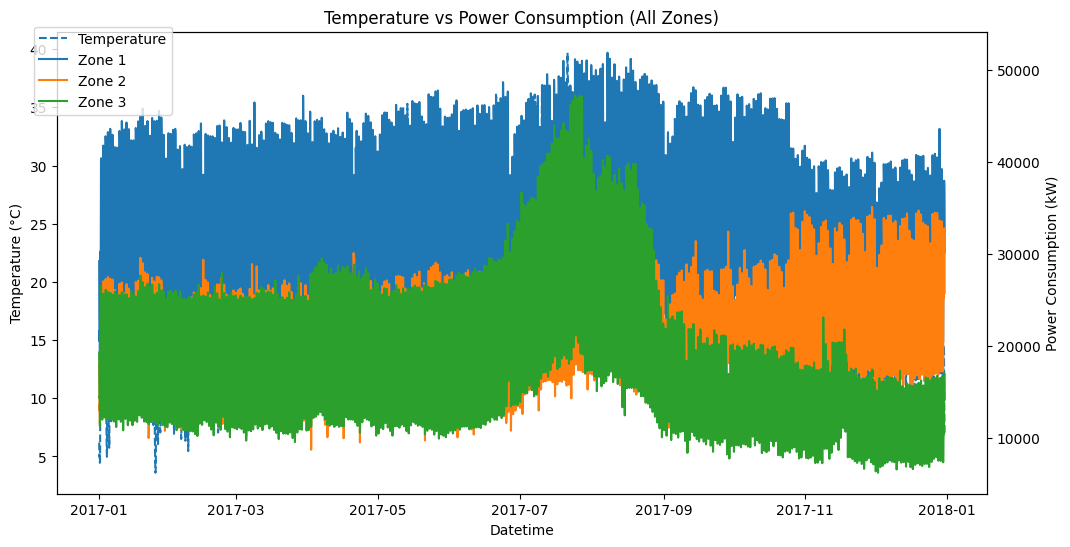

In [57]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(df_hourly.index,
         df_hourly['Temperature'],
         label='Temperature',
         linestyle='--')

ax1.set_xlabel("Datetime")
ax1.set_ylabel("Temperature (°C)")

ax2 = ax1.twinx()

ax2.plot(df_hourly.index,
         df_hourly['PowerConsumption_Zone1'],
         label='Zone 1')

ax2.plot(df_hourly.index,
         df_hourly['PowerConsumption_Zone2'],
         label='Zone 2')

ax2.plot(df_hourly.index,
         df_hourly['PowerConsumption_Zone3'],
         label='Zone 3')

ax2.set_ylabel("Power Consumption (kW)")

fig.legend(loc="upper left", bbox_to_anchor=(0.1,0.9))

plt.title("Temperature vs Power Consumption (All Zones)")
plt.show()


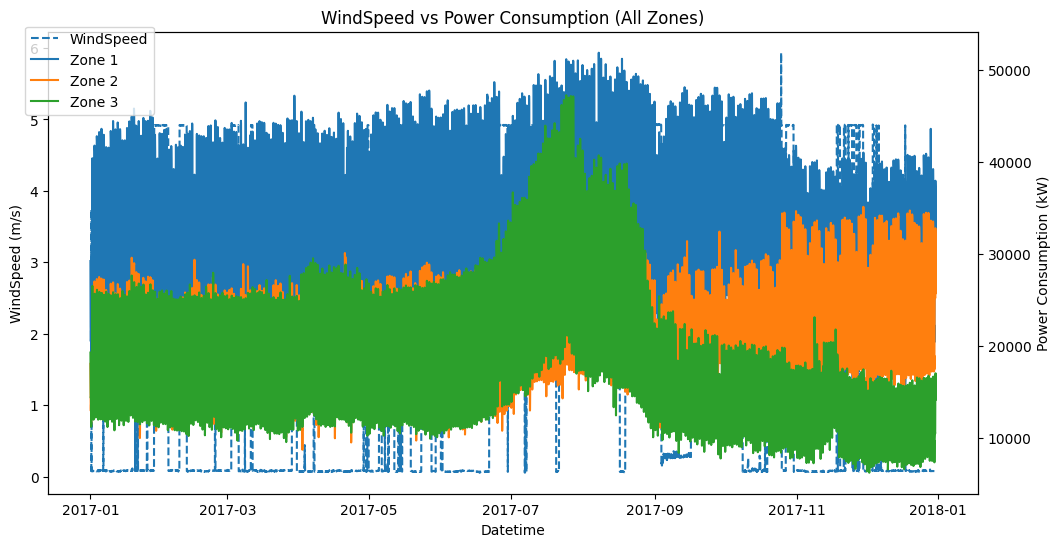

In [58]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(df_hourly.index,
         df_hourly['WindSpeed'],
         label='WindSpeed',
         linestyle='--')

ax1.set_xlabel("Datetime")
ax1.set_ylabel("WindSpeed (m/s)")

ax2 = ax1.twinx()

ax2.plot(df_hourly.index,
         df_hourly['PowerConsumption_Zone1'],
         label='Zone 1')

ax2.plot(df_hourly.index,
         df_hourly['PowerConsumption_Zone2'],
         label='Zone 2')

ax2.plot(df_hourly.index,
         df_hourly['PowerConsumption_Zone3'],
         label='Zone 3')

ax2.set_ylabel("Power Consumption (kW)")

fig.legend(loc="upper left", bbox_to_anchor=(0.1,0.9))

plt.title("WindSpeed vs Power Consumption (All Zones)")
plt.show()


In [59]:
df_hourly.dtypes

Temperature                float64
Humidity                   float64
WindSpeed                  float64
GeneralDiffuseFlows        float64
DiffuseFlows               float64
PowerConsumption_Zone1     float64
PowerConsumption_Zone2     float64
PowerConsumption_Zone3     float64
Hour                         int32
Day                         object
Month                        int32
Season                      object
Temp_Bins                 category
dtype: object

In [60]:
# droping the Temp_Bins columns

df_hourly.drop(["Temp_Bins"],axis=1,inplace=True)

In [61]:
df_hourly.columns

Index(['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows',
       'DiffuseFlows', 'PowerConsumption_Zone1', 'PowerConsumption_Zone2',
       'PowerConsumption_Zone3', 'Hour', 'Day', 'Month', 'Season'],
      dtype='object')

In [62]:
df_hourly['Season'].unique()

array(['Winter', 'Autumn', 'Summer', 'Monsoon'], dtype=object)

In [64]:
# Encoding the Day and Season column so that a machine can understand


# Days
df_hourly['Day'] = df_hourly['Day'].map({
    'Monday':0,
    'Tuesday':1,
    'Wednesday':2,
    'Thursday':3,
    'Friday':4,
    'Saturday':5,
    'Sunday':6
}).astype('int')

# Season
df_hourly['Season'] = df_hourly['Season'].map({
    'Winter':0,
    'Autumn':1,
    'Summer':2,
    'Monsoon':3
})

**Round Of The Data To Only 5 Decimal

In [65]:
df_hourly[df_hourly_numeric] = df_hourly[df_hourly_numeric].round(5)

In [66]:
df_hourly.head()

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,Hour,Day,Month,Season
Datetime,,,,,,,,,,,,
2017-01-01 00:00:00,6.19683,75.06667,0.08183,0.06350,0.09883,29197.97468,18026.74772,19252.04819,0,6,1,0
2017-01-01 01:00:00,5.54883,77.58333,0.08200,0.05683,0.11250,24657.21519,16078.41945,17042.89157,1,6,1,0
2017-01-01 02:00:00,5.05433,78.93333,0.08233,0.06300,0.12917,22083.03797,14330.69909,15676.14458,2,6,1,0
2017-01-01 03:00:00,5.00433,77.08333,0.08283,0.05983,0.14100,20811.13924,13219.45289,14883.85542,3,6,1,0
2017-01-01 04:00:00,5.09767,74.05000,0.08233,0.05800,0.12283,20475.94937,12921.58055,14317.10843,4,6,1,0


In [68]:
df_hourly['Hour'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

In [69]:
df_hourly['Month'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [67]:
import joblib

df_hourly.to_csv("EDA_Data.csv",index=True)
